In [1]:
#April 22, 2026
#Charlotte Meyer
#Data Seminar
#This code is runs KDE plots for predictors of the logistic regression.
# it uses "cejst_logistic_regression.csv"

#code is adapted from the following links: 
#https://www.geeksforgeeks.org/pandas/kde-plot-visualization-with-pandas-and-seaborn/
#https://datagy.io/seaborn-kdeplot/

In [2]:
# importing packages
from sklearn import datasets
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
#reading in the data
cejst = pd.read_csv("cejst_logistic_regression.csv", index_col=0)

#setting pandas columns so I can see all of them
pd.set_option('display.max_columns', None)

cejst

/var/folders/sl/dyq7sj0x2_z0dr2x82v1ln_80000gn/T/ipykernel_41552/3655311382.py:2: DtypeWarning: Columns (0: Identified as disadvantaged, 1: Greater than or equal to the 90th percentile for expected agriculture loss rate and is low income?, 2: Tract experienced historic underinvestment and remains low income, 3: no_plumbing, 4: There is at least one abandoned mine in this census tract and the tract is low income., 5: Percent of the Census tract that is within Tribal areas) have mixed types. Specify dtype option on import or set low_memory=False.
  cejst = pd.read_csv("cejst_logistic_regression.csv", index_col=0)


,GEOID,County Name,State,perc_black,perc_native_american,perc_asian,perc_hawaiin_pacific,perc_mixed_race,perc_white,perc_hispanic,Percent other races,perc_children,Percent age 10 to 64,perc_elderly,Total threshold criteria exceeded,Total categories exceeded,Identified as disadvantaged without considering neighbors,Identified as disadvantaged based on neighbors and relaxed low income threshold only,Identified as disadvantaged due to tribal overlap,Identified as disadvantaged,perc_disadvantaged,Share of neighbors that are identified as disadvantaged,Identified as disadvantaged in v1.0,Identified as disadvantaged solely due to status in v1.0 (grandfathered),population,Interpolated number of off-campus students in poverty,Adjusted percent of individuals below 200% Federal Poverty Line (percentile),perc_poverty,Is low income?,Income data has been estimated based on geographic neighbor income,Greater than or equal to the 90th percentile for expected agriculture loss rate and is low income?,Expected agricultural loss rate (Natural Hazards Risk Index) (percentile),Expected agricultural loss rate (Natural Hazards Risk Index),Greater than or equal to the 90th percentile for expected building loss rate and is low income?,Expected building loss rate (Natural Hazards Risk Index) (percentile),Expected building loss rate (Natural Hazards Risk Index),Greater than or equal to the 90th percentile for expected population loss rate and is low income?,Expected population loss rate (Natural Hazards Risk Index) (percentile),loss_rate,Share of properties at risk of flood in 30 years (percentile),flood_risk,Greater than or equal to the 90th percentile for share of properties at risk of flood in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of flood in 30 years and is low income?,Share of properties at risk of fire in 30 years (percentile),Share of properties at risk of fire in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of fire in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of fire in 30 years and is low income?,Greater than or equal to the 90th percentile for energy burden and is low income?,Energy burden (percentile),energy_burden,Greater than or equal to the 90th percentile for PM2.5 exposure and is low income?,PM2.5 in the air (percentile),pm_air,Greater than or equal to the 90th percentile for diesel particulate matter and is low income?,Diesel particulate matter exposure (percentile),diesel_exposure,Greater than or equal to the 90th percentile for traffic proximity and is low income?,Traffic proximity and volume (percentile),traffic_prox,Greater than or equal to the 90th percentile for DOT transit barriers and is low income?,travel_barriers,Greater than or equal to the 90th percentile for housing burden and is low income?,Housing burden (percent) (percentile),housing_burden,"Greater than or equal to the 90th percentile for lead paint, the median house value is less than 90th percentile and is low income?",Percent pre-1960s housing (lead paint indicator) (percentile),Percent pre-1960s housing (lead paint indicator),Median value ($) of owner-occupied housing units (percentile),house_value,Greater than or equal to the 90th percentile for share of the tract's land area that is covered by impervious surface or cropland as a percent and is low income?,Greater than or equal to the 90th percentile for share of the tract's land area that is covered by impervious surface or cropland as a percent,Share of the tract's land area that is covered by impervious surface or cropland as a percent,pavement_cropland,Does the tract have at least 35 acres in it?,Tract experienced historic underinvestment and remains low income,Tract experienced historic underinvestment,no_plumbing,Share of homes with no kitchen or indoor plumbing (percent),Greater than or equal to the 90th percentile for proximity to hazardous waste facilities and is low income?,

In [5]:
#this block is stratifying the sample size of the data so that the plots will be comparable
#because there are so few rows that contain a data center, we want a smaller sample of rows that don't contain a data center, 
# so that we can compare the shapes on the KDE plots

#dc = the number of rows that contain a data center
dc = cejst_df.loc[cejst_df['has_datacenter'] == 1]

#no_dc = the number of rows that don't contain a data center
no_dc = cejst_df.loc[cejst_df['has_datacenter'] == 0]

#a new dataframe named "stratified" contains all dc rows and a sample of no_dc rows that's the same size as dc
stratified = pd.concat([dc, no_dc.sample(n=dc.shape[0])])

#checking the shape of this dataframe
stratified.shape

Task was destroyed but it is pending!
task: <Task pending name='Task-326' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/charlottemeyer/anaconda3/envs/.da_401/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-327' coro=<Kernel.shell_main() running at /Users/charlottemeyer/anaconda3/envs/.da_401/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/charlottemeyer/anaconda3/envs/.da_401/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/charlottemeyer/anaconda3/envs/.da_401/lib/python3.12/site-packages/matplotlib/_api/__init__.py:86: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for k, v in kwargs.items():
Task was destroyed but it is pending!
task: <Task pending name='Task-327' coro=<Kernel.shell_main() running at /Users/charlottemeyer/anaconda3/envs/.da_401/lib/python3.12/site-packages/ipykernel/ker

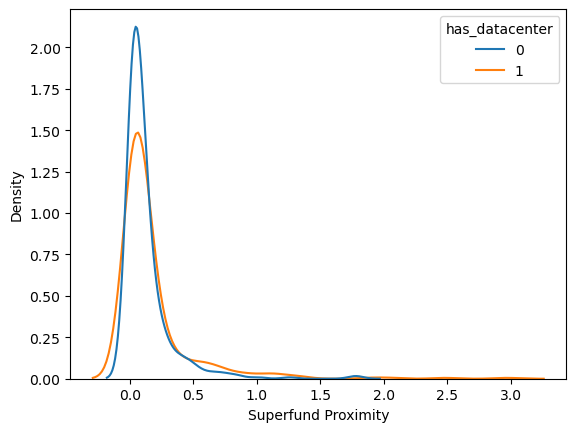

<Figure size 640x480 with 0 Axes>

In [26]:
#superfund_prox KDE plot
sns.kdeplot(data=stratified, x='superfund_prox', hue='has_datacenter')
plt.xlabel("Superfund Proximity")
plt.show()
plt.savefig("superfund_prox_KDE.jpg")

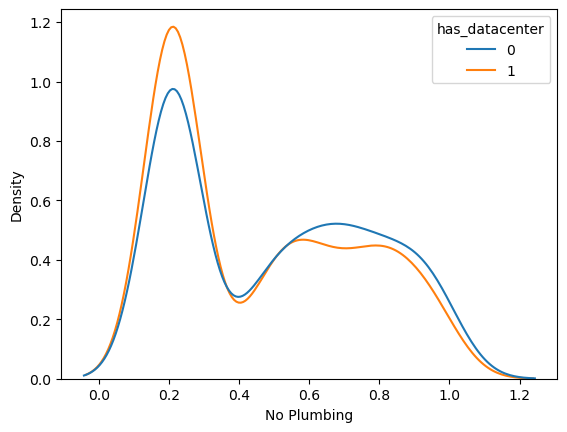

<Figure size 640x480 with 0 Axes>

In [25]:
#no_plumbing KDE plot
sns.kdeplot(data=stratified, x='no_plumbing', hue='has_datacenter')
plt.xlabel("No Plumbing")
plt.show()
plt.savefig("no_plumbing_KDE.jpg")

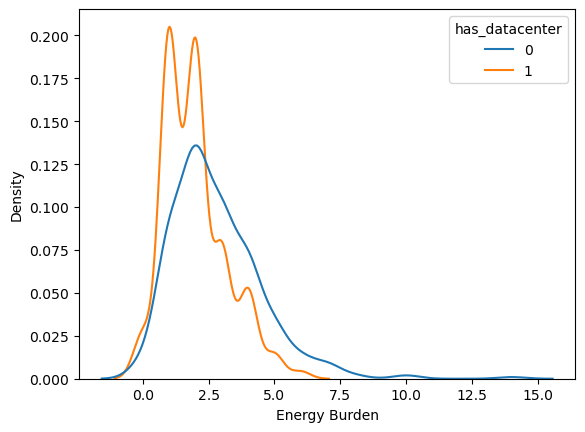

<Figure size 640x480 with 0 Axes>

In [24]:
#energy_burden KDE plot
sns.kdeplot(data=stratified, x='energy_burden', hue='has_datacenter')
plt.xlabel("Energy Burden")
plt.show()
plt.savefig("energy_burden_KDE.jpg")

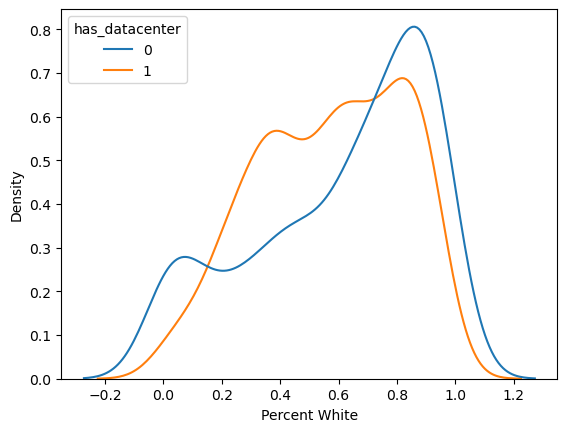

<Figure size 640x480 with 0 Axes>

In [23]:
#perc_white KDE plot
sns.kdeplot(data=stratified, x='perc_white', hue='has_datacenter')
plt.xlabel("Percent White")
plt.show()
plt.savefig("perc_white_KDE.jpg")

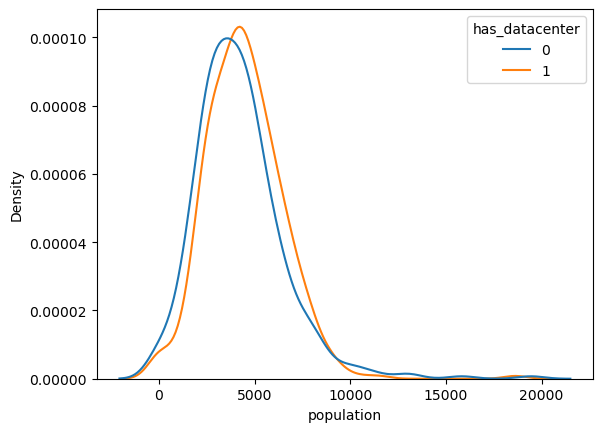

In [7]:
#population KDE plot
sns.kdeplot(data=stratified, x='population', hue='has_datacenter')
plt.show()

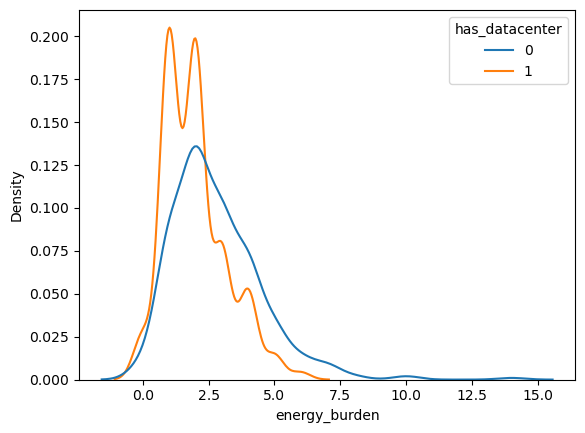

In [8]:
#energy_burden KDE plot
sns.kdeplot(data=stratified, x='energy_burden', hue='has_datacenter')
plt.show()

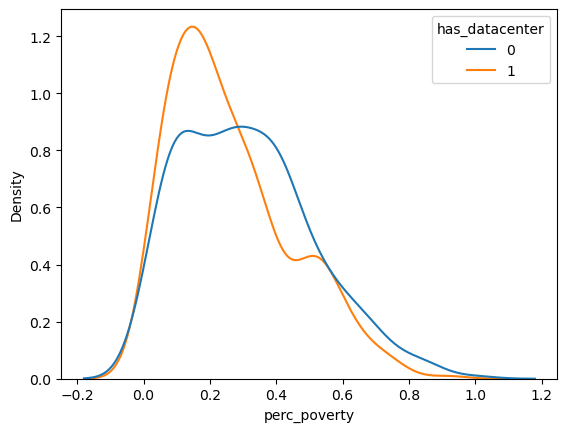

In [10]:
#perc_poverty KDE plot
sns.kdeplot(data=stratified, x='perc_poverty', hue='has_datacenter')
plt.show()

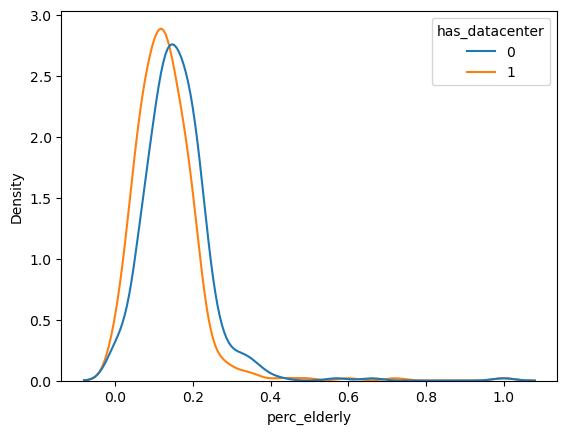

In [12]:
#perc_elderly KDE plot
sns.kdeplot(data=stratified, x='perc_elderly', hue='has_datacenter')
plt.show()

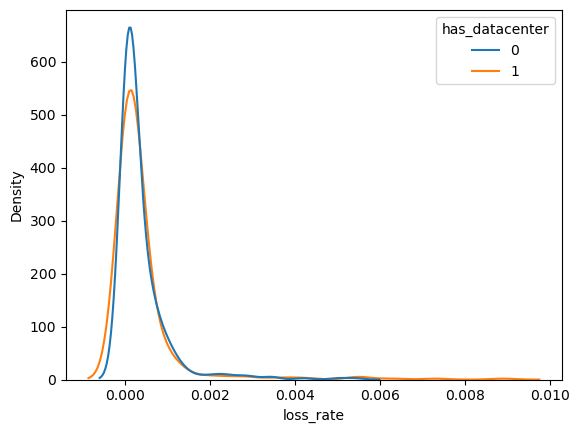

In [14]:
#loss_rate KDE plot
sns.kdeplot(data=stratified, x='loss_rate', hue='has_datacenter')
plt.show()